In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from moco.loader import *
from moco.stain_augmentation import *
import matplotlib.pyplot as plt
import moco

In [3]:
dataset = TileDataset("/home/maelmontillet/primacode/images/train")

In [4]:
len(dataset)

6

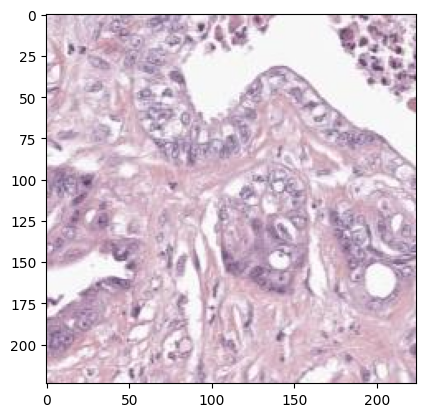

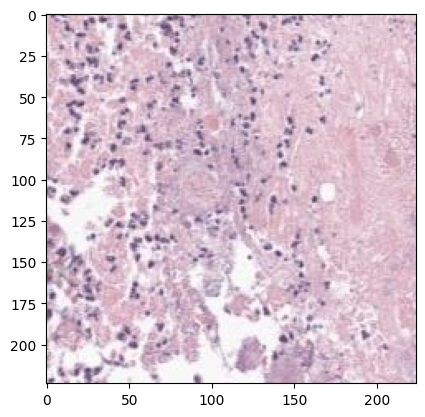

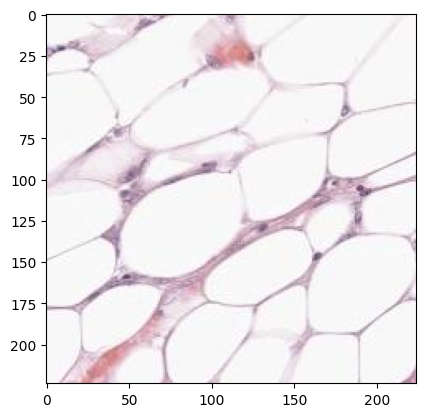

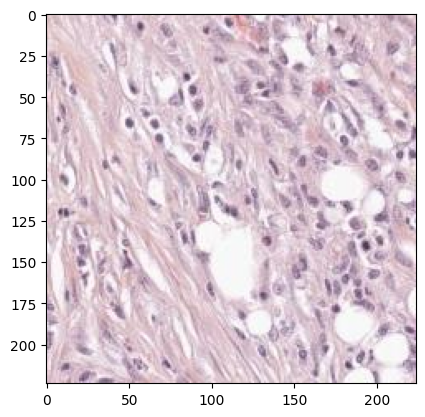

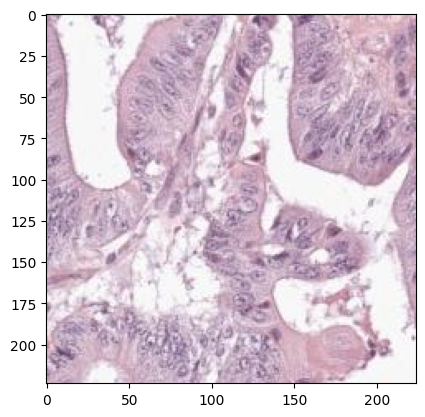

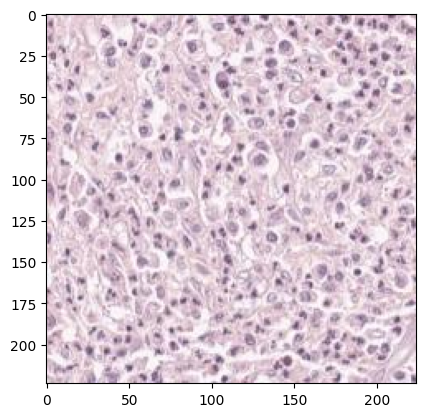

In [5]:
for img in dataset:
    plt.imshow(img)
    plt.show()

In [6]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

augmentation1 = [
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.2, 1.)),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=1.0),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
]

augmentation2 = [
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.2, 1.)),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)  # not strengthened
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([moco.loader.GaussianBlur([.1, 2.])], p=0.1),
    transforms.RandomApply([moco.loader.Solarize()], p=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
]

collate_fn = MyCollateFunction(transforms.Compose(augmentation1), 
                                                          transforms.Compose(augmentation2), 
                                                          moco.stain_augmentation.all_free_version())

# Num worker

train_loader = DataLoader(dataset, batch_size=2, shuffle=True, 
                        collate_fn = collate_fn, 
                        pin_memory=True,  drop_last=True,
                        #num_workers=1,
                       )

0


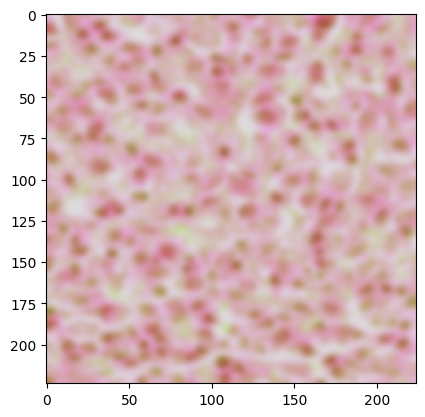

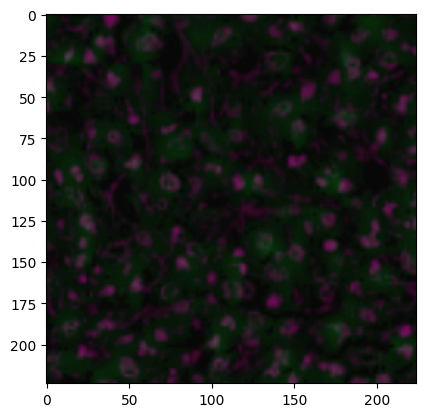

1


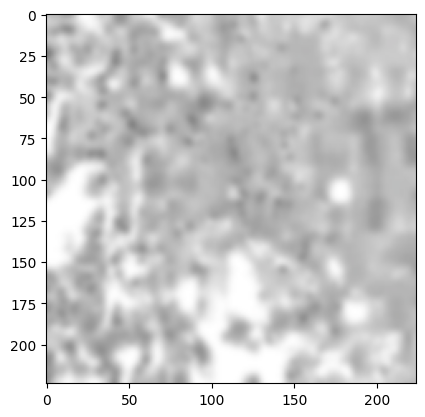

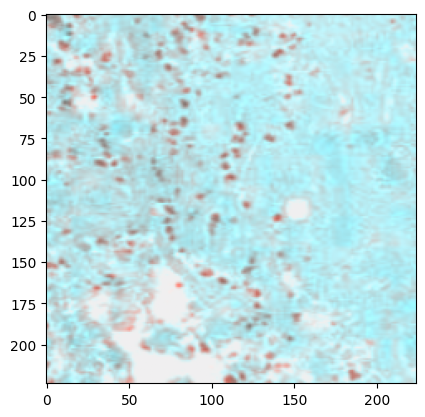

0


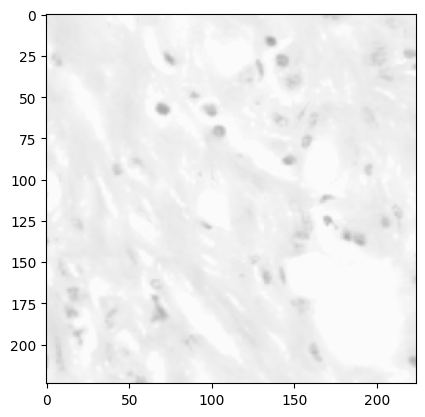

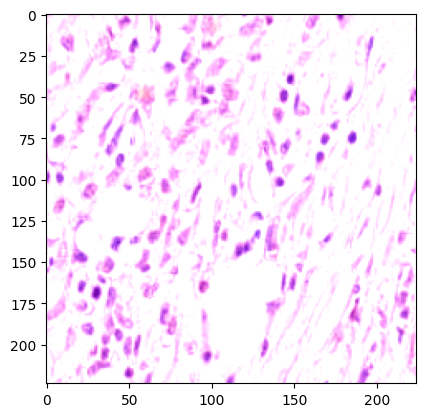

1


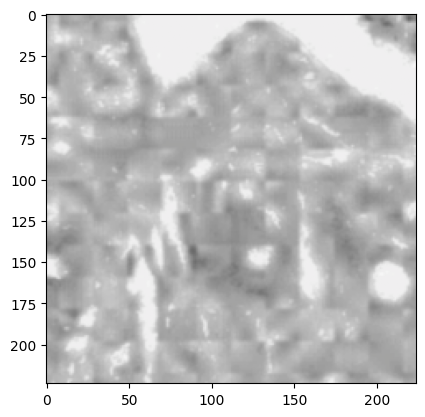

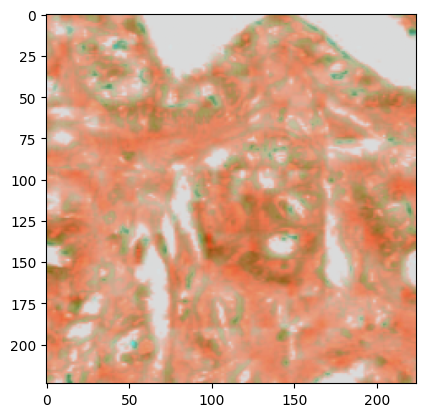

0


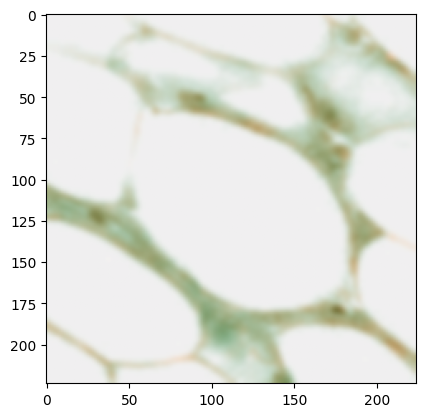

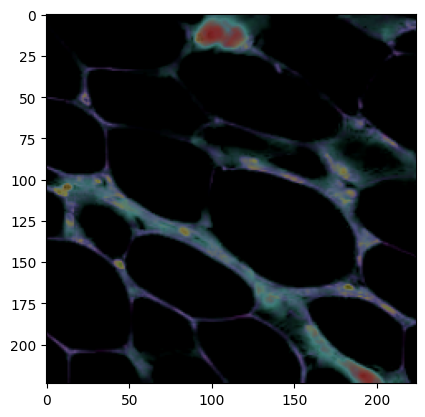

1


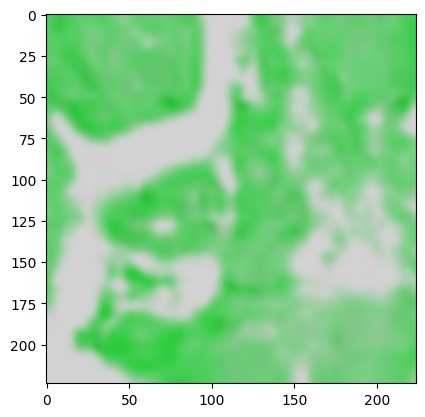

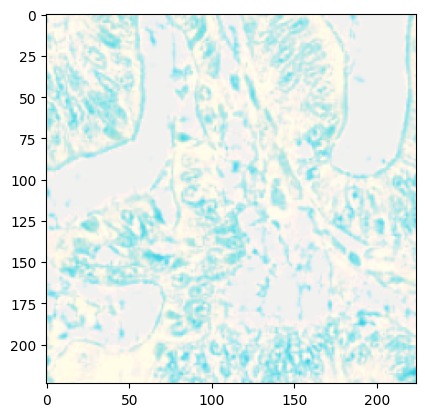

In [7]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)
for i, (images, _) in enumerate(train_loader):
    for i in range(len(images[0])):
        images[0] = images[0].cuda()
        images[1] = images[1].cuda()
        print(i)
        plt.imshow(inv_normalize(images[0][i].cpu()).permute(1, 2, 0))
        plt.show()
        plt.imshow(inv_normalize(images[1][i].cpu()).permute(1, 2, 0))
        plt.show()

In [8]:
import os

os.path.join("test/test1", "*.tar")

'test/test1/*.tar'

# Test Virchow2

In [9]:
from stamp.preprocessing.extractor.virchow2 import virchow2

/home/maelmontillet/STAMP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
model = virchow2()

In [11]:
model

Extractor(model=Virchow2ClsOnly(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): GluMlp(
          (fc1): Linear(in_features=1280, out_feature

In [12]:
img = v2.ToTensor()(img)

/home/maelmontillet/STAMP/.venv/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [13]:
output = model.model(img.unsqueeze(0))

In [14]:
repeat = torch.stack([img] * 50)
repeat.shape

torch.Size([50, 3, 224, 224])

In [15]:
stain_matrix_mins: Tuple[float, float] = ((0.75, 0.80), (0.15, 0.2), (0.4, 0.6)),
stain_matrix_maxs: Tuple[float, float] = ((0.80, 1), (0.6, 0.7), (0.8, 0.9))
augmentor = StainAugmentor(od_mins=(0.5, 0.5), od_maxs=(2, 2), stain_matrix_mins=stain_matrix_mins,
                          stain_matrix_maxs=stain_matrix_maxs, color_system="hsv")
#augmentor = all_free_version()

In [16]:
augmented = augmentor(repeat)

In [17]:
augmented.shape

torch.Size([50, 3, 224, 224])

In [18]:
aug_output = model.model(augmented)

In [19]:
aug_output.shape

torch.Size([50, 1280])

In [20]:
all_out = torch.concatenate([output, aug_output]).detach().numpy()
all_out.shape

(51, 1280)

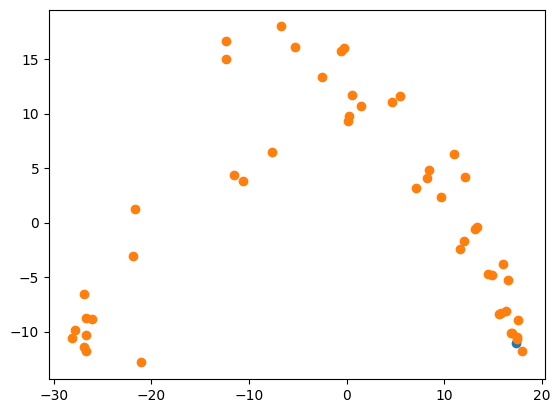

In [21]:
from sklearn.decomposition import PCA

my_pca = PCA(2)
transformed = my_pca.fit_transform(all_out)

plt.scatter(transformed[0, 0], transformed[0, 1])
plt.scatter(transformed[1:, 0], transformed[1:, 1])

/home/maelmontillet/STAMP/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


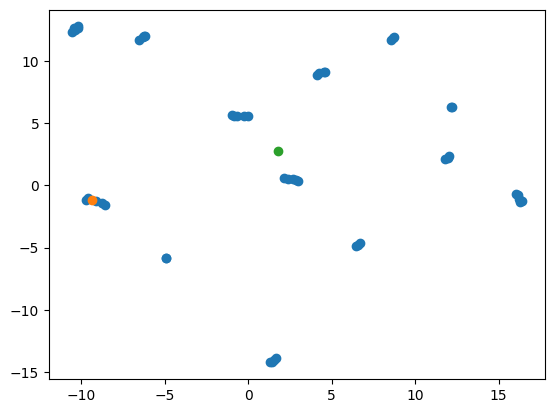

In [22]:
from umap import UMAP

my_umap = UMAP(2)
transformed = my_umap.fit_transform(all_out)

plt.scatter(transformed[1:, 0], transformed[1:, 1])
plt.scatter(transformed[0, 0], transformed[0, 1])
plt.scatter(transformed[1:, 0].mean(), transformed[1:, 1].mean())

In [23]:
from itertools import combinations
import torch.nn.functional as F

def mean_distance(embeddings, pairwise=True):
    if pairwise:
        pairs = list(combinations(range(len(embeddings)), 2))
    else:
        pairs = [(0, i) for i in range(1, len(embeddings))]
    distances = [
        1 - F.cosine_similarity(embeddings[i].unsqueeze(0), embeddings[j].unsqueeze(0))
        for i, j in pairs
    ]
    return torch.stack(distances).mean().item()

    

In [24]:
print(mean_distance(torch.concatenate([output, aug_output])))
print(mean_distance(torch.concatenate([output, aug_output]), False))

0.4982298016548157
0.48742058873176575


In [26]:
imgs = []
for im in dataset:
    imgs.append(im)
imgs = torch.stack(v2.ToTensor()(imgs))

mean_distance(imgs)

0.0008795869071036577

In [27]:
48 + 9 + 7

64